# 实验2 复杂网络基本拓扑性质分析


1. 无向有权网络 `my_network1.csv`
2. 有向网络 `my_network2.csv`
3. 真实网络 `power.csv


## 1. 计算无向有权网络节点的加权度、边权、网络的平均度、度分布


网络节点的加权度
[(1, 6), (2, 3), (3, 7), (4, 4), (5, 3), (6, 7), (7, 6), (8, 6), (9, 4), (10, 4)]
网络的边权
2 2 2 1 3 3 1 4 1 2 1 3 
网络平均度为： 5.0


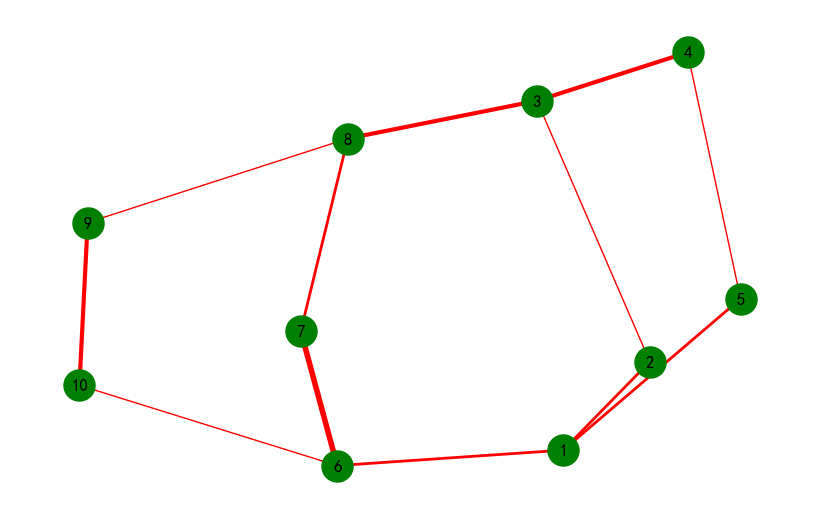

In [46]:
# 构建无向有权网络
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv

plt.rc('font', family='SimHei')
G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
G.add_weighted_edges_from([
    (1,2,2), (2,3,1), (3,4,3), (4,5,1), (5,1,2),
    (6,7,4), (7,8,2), (8,9,1), (9,10,3), (10,6,1),
    (1,6,2), (3,8,3)
])

# 获取网络节点的加权度
print("网络节点的加权度")
print(nx.degree(G, weight='weight'), end='\n')

# 获取每条边的权重（即边权）
print("网络的边权")
for e in G.edges():
    print(G[e[0]][e[1]]['weight'], end=' ')

# 获取平均度
d = dict(nx.degree(G, weight='weight'))
print("\n网络平均度为：", sum(d.values()) / len(G.nodes))

w = [G[e[0]][e[1]]['weight'] for e in G.edges()]
nx.draw(G, node_size=500, width=w, with_labels=True, node_color='green', edge_color='red')
plt.show()


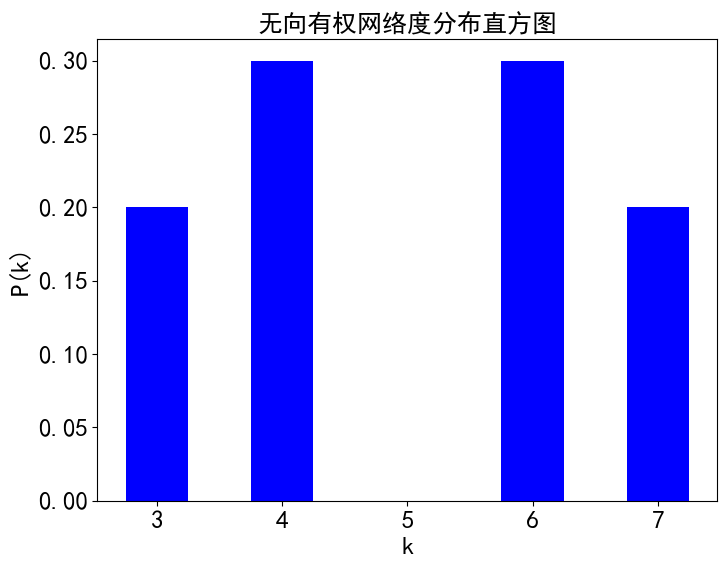

In [48]:
# 定义函数get_pdf计算度分布
def get_pdf(G):
    all_k = [G.degree(i, weight='weight') for i in G.nodes()]
    k = list(set(all_k))
    N = len(G.nodes())

    Pk = []
    for ki in sorted(k):
        c = 0
        for i in G.nodes():
            if G.degree(i, weight='weight') == ki:
                c += 1
        Pk.append(c / N)

    return sorted(k), Pk


mid_d, p = get_pdf(G)

# 绘制网络G的度分布直方图
width = 0.5
plt.figure(figsize=(8, 6))
plt.bar(mid_d, p, width, color='b')
plt.title("无向有权网络度分布直方图", fontsize=18)
plt.xlabel("k", fontsize=18)
plt.ylabel("P(k)", fontsize=18)
plt.tick_params(labelsize=18)
plt.show()


## 2. 计算无向有权网络的直径、最短路径、最短路径长度、网络密度、聚类系数等拓扑参数


网络的直径为： 4
节点1和8的最短路径 [1, 2, 3, 8]
节点1和8的所有的最短路径 [[1, 2, 3, 8], [1, 6, 7, 8]]
节点1和8的最短路径长度 3
网络的平均路径长度 2.111111111111111
网络的密度为： 0.26666666666666666
节点的聚类系数： {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}
网络的平均聚类系数 0.0
网络的全局聚类系数 0


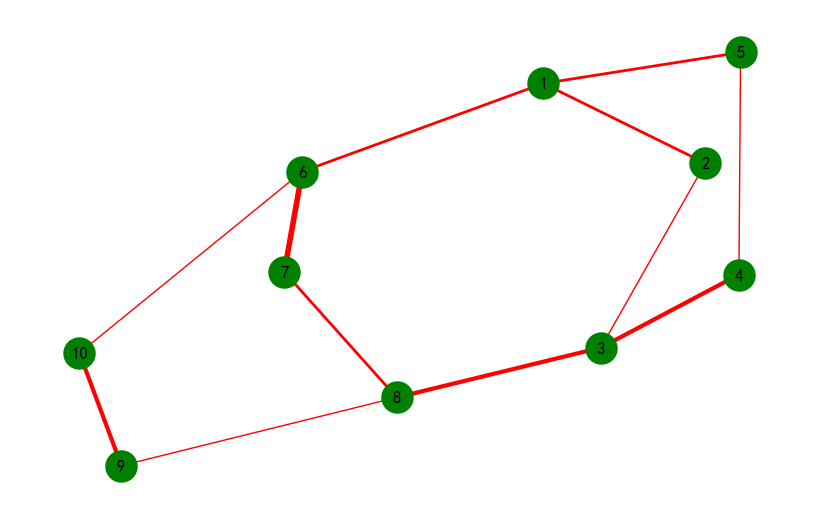

In [51]:
# 计算网络的直径、最短路径、最短路径长度、平均路径长度、网络密度
import networkx as nx
import matplotlib.pyplot as plt

print("网络的直径为：", nx.diameter(G))
print("节点1和8的最短路径", nx.shortest_path(G, source=1, target=8))
print("节点1和8的所有的最短路径", list(nx.all_shortest_paths(G, source=1, target=8)))
print("节点1和8的最短路径长度", nx.shortest_path_length(G, source=1, target=8))
print("网络的平均路径长度", nx.average_shortest_path_length(G))
print("网络的密度为：", nx.density(G))
print("节点的聚类系数：", nx.clustering(G))
print("网络的平均聚类系数", nx.average_clustering(G))
print("网络的全局聚类系数", nx.transitivity(G))

w = [G[e[0]][e[1]]['weight'] for e in G.edges()]
nx.draw(G, node_size=500, width=w, with_labels=True, node_color='green', edge_color='red')
plt.show()


## 3. 计算有向网络节点的入度、出度、网络的平均度、度分布


节点的入度 [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 1), (8, 2), (9, 1), (10, 1)]
节点的出度 [(1, 2), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1)]
网络的平均入度为： 1.2
网络的平均出度为： 1.2


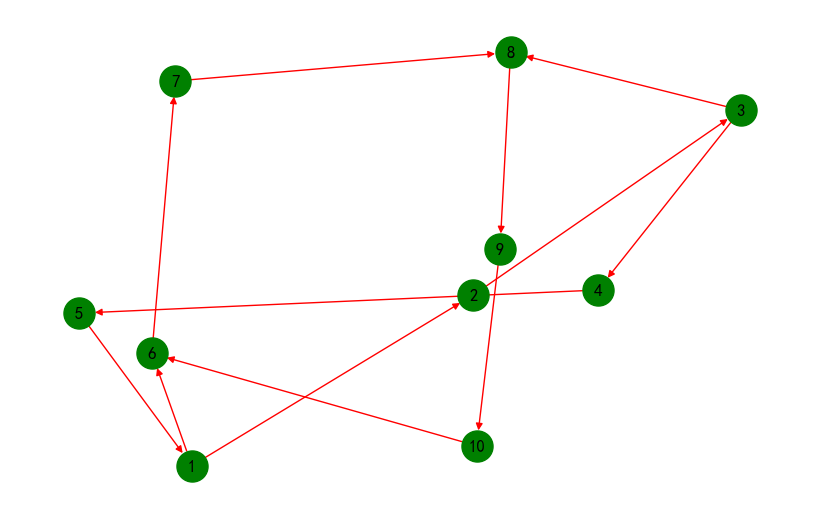

In [54]:
# 构建有向网络
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

DG = nx.DiGraph()
DG.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
DG.add_edges_from([(1,2), (2,3), (3,4), (4,5), (5,1), (6,7), (7,8), (8,9), (9,10), (10,6), (1,6), (3,8)])

print("节点的入度", DG.in_degree(DG), end="\n")
print("节点的出度", DG.out_degree(DG), end="\n")

# 获取平均入度
d1 = dict(DG.in_degree(DG))
print("网络的平均入度为：", sum(d1.values()) / len(DG.nodes))

# 获取平均出度
d2 = dict(DG.out_degree(DG))
print("网络的平均出度为：", sum(d2.values()) / len(DG.nodes))

nx.draw(DG, node_color="green", edge_color="red", node_size=500, with_labels=True)
plt.show()


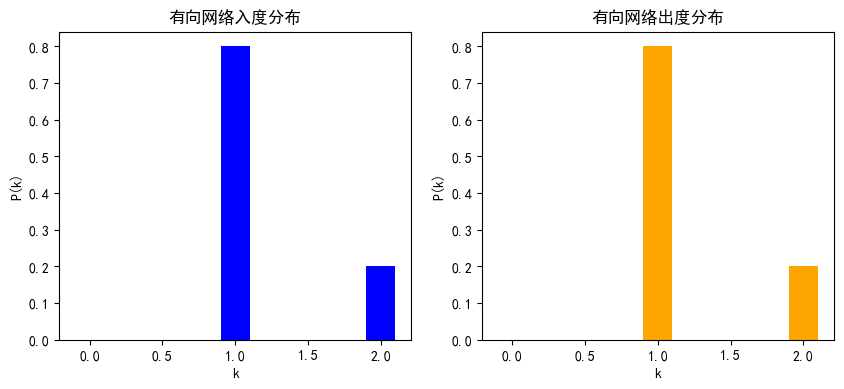

In [56]:
# 计算有向网络入度分布和出度分布
in_d = dict(DG.in_degree(DG))
out_d = dict(DG.out_degree(DG))

x1 = list(range(max(in_d.values()) + 1))
y1 = []
for k in x1:
    c = 0
    for i in DG.nodes():
        if DG.in_degree(i) == k:
            c += 1
    y1.append(c / len(DG.nodes))

x2 = list(range(max(out_d.values()) + 1))
y2 = []
for k in x2:
    c = 0
    for i in DG.nodes():
        if DG.out_degree(i) == k:
            c += 1
    y2.append(c / len(DG.nodes))

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.bar(x1, y1, width=0.2, color='blue')
plt.xlabel("k")
plt.ylabel("P(k)")
plt.title("有向网络入度分布")

plt.subplot(122)
plt.bar(x2, y2, width=0.2, color='orange')
plt.xlabel("k")
plt.ylabel("P(k)")
plt.title("有向网络出度分布")
plt.show()


## 4. 计算有向网络的直径、最短路径、最短路径长度、网络密度、聚类系数等拓扑参数


网络的直径为： 4
节点1和8的最短路径 [1, 2, 3, 8]
节点1和8的所有的最短路径 [[1, 2, 3, 8], [1, 6, 7, 8]]
节点1和8的最短路径长度 3
网络的平均路径长度 2.111111111111111
网络的密度为： 0.13333333333333333
节点的聚类系数： {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}
网络的平均聚类系数 0.0
网络的全局聚类系数 0


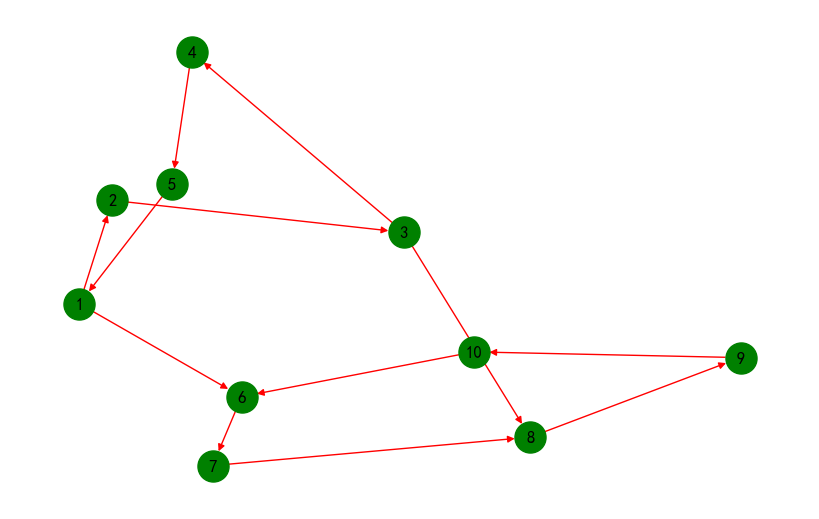

In [59]:
# 将有向网络转成无向网络后计算拓扑参数
import networkx as nx
import matplotlib.pyplot as plt

UG = DG.to_undirected()

print("网络的直径为：", nx.diameter(UG))
print("节点1和8的最短路径", nx.shortest_path(UG, source=1, target=8))
print("节点1和8的所有的最短路径", list(nx.all_shortest_paths(UG, source=1, target=8)))
print("节点1和8的最短路径长度", nx.shortest_path_length(UG, source=1, target=8))
print("网络的平均路径长度", nx.average_shortest_path_length(UG))
print("网络的密度为：", nx.density(DG))
print("节点的聚类系数：", nx.clustering(UG))
print("网络的平均聚类系数", nx.average_clustering(UG))
print("网络的全局聚类系数", nx.transitivity(UG))

nx.draw(DG, node_color="green", edge_color="red", node_size=500, with_labels=True)
plt.show()


## 5. 计算真实网络节点的度、网络的平均度、度分布


In [62]:
# 真实网络度分布直方图
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv
from pathlib import Path

plt.rc('font', family='SimHei')
base_dir = Path.cwd().parents[1] / '实验一'
path3 = base_dir / '实验1 不同类型复杂网络的构建及读取' / 'power.csv'
df = pd.read_csv(path3)
G = nx.from_pandas_edgelist(df, 'source', 'target', create_using=nx.Graph())

# 获取网络节点的度
print("网络节点的度")
print(nx.degree(G), end='\n')

# 获取平均度
d = dict(nx.degree(G))
print("\n网络平均度为：", sum(d.values()) / len(G.nodes))


网络节点的度
[(8, 3), (6, 1), (7, 1), (9, 6), (10, 2), (13, 5), (5, 2), (12, 1), (14, 5), (15, 1), (16, 1), (17, 1), (19, 3), (18, 2), (20, 2), (29, 3), (34, 3), (33, 1), (35, 5), (36, 6), (37, 1), (38, 1), (39, 1), (42, 3), (41, 5), (47, 5), (44, 1), (45, 1), (46, 2), (50, 3), (51, 3), (21, 2), (53, 2), (24, 2), (58, 4), (25, 2), (59, 2), (60, 2), (61, 3), (62, 2), (31, 2), (68, 6), (63, 1), (64, 1), (65, 1), (69, 7), (66, 1), (70, 3), (67, 1), (73, 3), (72, 3), (75, 2), (48, 3), (77, 3), (76, 4), (79, 2), (78, 2), (80, 4), (82, 2), (81, 2), (83, 3), (86, 3), (71, 2), (88, 8), (4, 1), (55, 2), (87, 2), (89, 1), (90, 1), (91, 3), (94, 7), (11, 2), (26, 4), (43, 2), (92, 3), (93, 1), (95, 3), (97, 2), (40, 2), (98, 9), (28, 1), (57, 2), (74, 1), (100, 2), (99, 2), (101, 3), (104, 3), (106, 2), (107, 2), (108, 4), (109, 2), (54, 2), (110, 2), (111, 4), (52, 3), (112, 3), (113, 3), (115, 2), (114, 1), (116, 5), (117, 1), (118, 1), (119, 4), (56, 5), (120, 2), (122, 2), (121, 1), (123, 5), (30, 

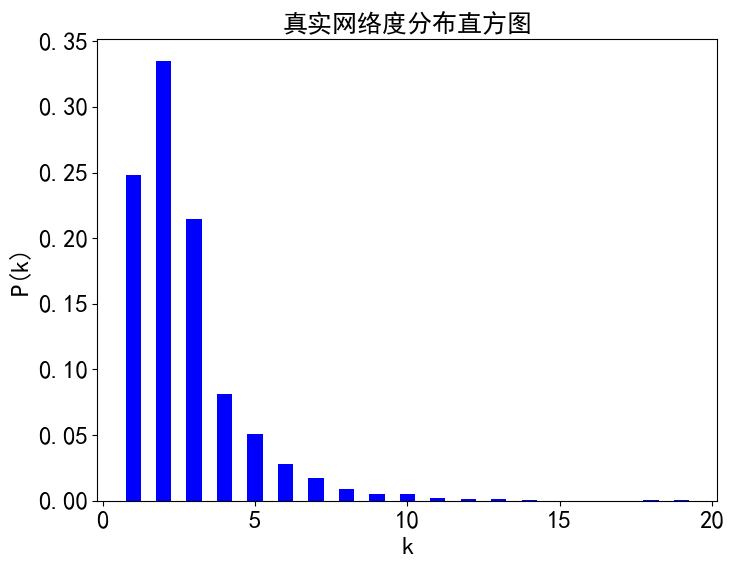

In [64]:
# 定义函数get_pdf计算度分布
def get_pdf(G):
    all_k = [G.degree(i) for i in G.nodes()]
    k = list(set(all_k))
    N = len(G.nodes())

    Pk = []
    for ki in sorted(k):
        c = 0
        for i in G.nodes():
            if G.degree(i) == ki:
                c += 1
        Pk.append(c / N)

    return sorted(k), Pk


mid_d, p = get_pdf(G)

# 绘制网络G的度分布直方图
width = 0.5
plt.figure(figsize=(8, 6))
plt.bar(mid_d, p, width, color='b')
plt.title("真实网络度分布直方图", fontsize=18)
plt.xlabel("k", fontsize=18)
plt.ylabel("P(k)", fontsize=18)
plt.tick_params(labelsize=18)
plt.show()


## 6. 计算真实网络的直径、平均路径长度、网络密度、节点聚类系数、网络聚类系数、横截性


In [67]:
# 真实网络的直径、平均路径长度、网络密度、节点的聚类系数、网络的聚类系数、网络的横截性
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv
from pathlib import Path

base_dir = Path.cwd().parents[1] / '实验一'
path3 = base_dir / '实验1 不同类型复杂网络的构建及读取' / 'power.csv'
df = pd.read_csv(path3)
G = nx.from_pandas_edgelist(df, 'source', 'target', create_using=nx.Graph())

print("网络的直径为：", nx.diameter(G))
print("网络的平均路径长度", nx.average_shortest_path_length(G))
print("网络的密度为：", nx.density(G))
print("节点的聚类系数：", nx.clustering(G))
print("网络的平均聚类系数", nx.average_clustering(G))
print("网络的全局聚类系数", nx.transitivity(G))


网络的直径为： 46
网络的平均路径长度 18.989185424445708
网络的密度为： 0.0005403026973346214
节点的聚类系数： {8: 0, 6: 0, 7: 0, 9: 0, 10: 0, 13: 0, 5: 0, 12: 0, 14: 0, 15: 0, 16: 0, 17: 0, 19: 0, 18: 0, 20: 0, 29: 0, 34: 0, 33: 0, 35: 0.1, 36: 0, 37: 0, 38: 0, 39: 0, 42: 0, 41: 0.1, 47: 0, 44: 0, 45: 0, 46: 0, 50: 0, 51: 0, 21: 0, 53: 0, 24: 0, 58: 0.16666666666666666, 25: 0, 59: 0, 60: 0, 61: 0, 62: 0, 31: 0, 68: 0, 63: 0, 64: 0, 65: 0, 69: 0, 66: 0, 70: 0, 67: 0, 73: 0, 72: 0.3333333333333333, 75: 0, 48: 0, 77: 0, 76: 0.16666666666666666, 79: 0, 78: 0, 80: 0, 82: 0, 81: 0, 83: 0, 86: 0.3333333333333333, 71: 0, 88: 0, 4: 0, 55: 0, 87: 0, 89: 0, 90: 0, 91: 0, 94: 0.047619047619047616, 11: 0, 26: 0.3333333333333333, 43: 0, 92: 0, 93: 0, 95: 0, 97: 0, 40: 0, 98: 0, 28: 0, 57: 0, 74: 0, 100: 0, 99: 0, 101: 0, 104: 0, 106: 0, 107: 0, 108: 0.16666666666666666, 109: 0, 54: 0, 110: 1.0, 111: 0, 52: 0, 112: 0.3333333333333333, 113: 0, 115: 0, 114: 0, 116: 0.1, 117: 0, 118: 0, 119: 0.16666666666666666, 56: 0.3, 120: 0, 122: